# Generator-level event displays

Single simulated events from chosen points of the 2018 signal grid, drawn
directly from the generator record (`GenPart`) of one ntuple file per sample.
**No selections of any kind are applied**: no trigger, no reconstruction, no
kinematic cuts; the event shown is chosen by the deterministic rule described
below, not by hand.

Each figure has two panels:

- **Left ($\eta$-$\phi$):** the two dark photons (stars) with the
  $\Delta R = 0.4$ lepton-jet clustering cone drawn around each (dashed
  circle), and their daughter leptons (circles: muons; squares: electrons;
  marker area grows with $p_T$). This panel shows the collimation (both
  daughters of a dark photon sit inside one clustering cone) and the
  back-to-back topology, $\Delta\phi(Z_d, Z_d) \approx \pi$.
- **Right (signed $R$-$z$):** the same event in the longitudinal view,
  with the two halves of the detector unfolded: objects at $\phi > 0$ are
  drawn at positive $R$ and objects at $\phi < 0$ at negative $R$ (the
  hemisphere is assigned by the parent dark photon's $\phi$), so the
  back-to-back topology shows in this view as well, and the
  $|\Delta\phi|$/$|\Delta\eta|$ between the two dark photons is quoted on
  the panel. Each dark photon flies from its production vertex (the
  bound-state decay point, black dot, drawn at its true $z$, which the
  beamspot spreads by centimeters) to its decay vertex (star, annotated
  with the decay flavor, $p_T$, and $l_{xy}$ computed
  decay-minus-production); the daughter leptons emerge as straight rays
  from the decay vertex. Gray bands mark the schematic barrel radial
  extents of the pixel detector (3-16 cm), the outer tracker (20-110 cm),
  the ECAL (129-177 cm), and the muon system (400-740 cm), drawn only
  where the axis range reaches them (HCAL and solenoid omitted for
  clarity); the dotted line is the beam pipe. Rays are drawn without
  magnetic-field curvature: at the lepton $p_T$ shown here the bending
  radius is several to tens of meters, far larger than the tracker.

**Event choice rule:** among the first file's events in which every signal
lepton has $|\eta| < 2.4$, take the event whose larger dark-photon $l_{xy}$
is closest to the sample median of that quantity, a typical event, not a
tail event. The two muon-system displays instead target a stated $l_{xy}$
(350 and 550 cm): the region they illustrate lies in the lifetime tail,
above any sample's median, and the rule stays deterministic. Those two
displays additionally require the dark photons in opposite $\phi$
hemispheres, so the unfolded longitudinal view separates them.

**Reading the longitudinal view:** back-to-back is a transverse-plane
statement. $|\Delta\phi(Z_d, Z_d)| \approx \pi$ in every event (quoted on
each panel), but $\Delta\eta$ is not protected: the colliding partons
carry unequal momentum fractions, so the pair recoils with a longitudinal
boost and both dark photons often fly toward the same end of the detector
(the wide long-lived corner below has $|\Delta\eta| = 0.03$). The signed
$R$-$z$ view therefore shows anything from a clean up-down mirror to a
narrow "V" opening toward one side, all with exact transverse balance.

The first four samples step through roughly a decade of displacement each
while also scanning the collimation; the remaining displays illustrate
specific features of the signature, with both channels represented across
the feature set:

| sample | $\langle l_{xy}\rangle$ scale | what it illustrates |
|---|---|---|
| `2Mu2E_500GeV_1p2GeV_0p019mm` | ~0.4 cm | boosted, nearly prompt: tight $\mu$-jet back-to-back with a tight $e$-jet |
| `4Mu_200GeV_1p2GeV_0p48mm` | ~4 cm | the sweet spot: collimated pairs, vertices beyond the beampipe, inside the pixels |
| `4Mu_1000GeV_0p25GeV_0p2mm` | ~20 cm | extreme collimation, $\Delta R \sim 10^{-3}$, mid-tracker vertices |
| `2Mu2E_100GeV_5p0GeV_200mm` | ~1 m | wide pairs near the cone size, decays reaching beyond the tracker in the tail |
| `4Mu_100GeV_0p25GeV_0p2mm` | ~4 cm | the trigger-marginal corner: ~25 GeV muons straddling the dimuon thresholds |
| `4Mu_200GeV_1p2GeV_48p0mm` | ~4 m | beyond-tracker decays: the displaced-standalone-muon regime |
| `4Mu_200GeV_1p2GeV_48p0mm` (target 350 cm) | n/a | just upstream of the muon system: no tracker or calorimeter handle, full DSA lever arm |
| `4Mu_500GeV_0p25GeV_4p0mm` (target 550 cm) | n/a | inside the muon system: an extreme-collimation pair appearing between stations |
| `2Mu2E_200GeV_1p2GeV_0p48mm` | ~4 cm | the sweet spot in the electron channel: a displaced electron jet inside the pixels |
| `2Mu2E_100GeV_0p25GeV_0p2mm` | ~4 cm | the hardest trigger corner of the electron channel: one soft tight muon pair carries the trigger |
| `2Mu2E_200GeV_1p2GeV_48p0mm` (target 250 cm) | n/a | a late decay past the calorimeters: an electron pair born there is lost entirely |

In [1]:
import os
import sys

import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Circle
from coffea.nanoevents import NanoEventsFactory

here = os.getcwd()
repo = here.split("/sidm")[0]
for p in (repo, os.path.join(repo, "sidm", "studies", "truth_kinematics_forAN")):
    if p not in sys.path:
        sys.path.insert(1, p)
from sidm.tools import utilities, llpnanoaodschema
import _anatomy_lib as lib
import an_style

an_style.set_style()

def dphi(a, b):
    return np.mod(a - b + np.pi, 2 * np.pi) - np.pi

def format_sample_2line(name):
    p = lib.parse_sample(name)
    return (rf"{p['mode']}, $m_{{B_s}}$ = {p['mbs']:g} GeV" "\n"
            rf"$m_{{Z_d}}$ = {p['mzd']:g} GeV, $c\tau$ = {p['ctau_mm']:g} mm")

def corner_clearance(pts_ax, corner):
    '''Chebyshev distance (axes fraction) from a corner to the nearest point.'''
    return min((max(abs(px - corner[0]), abs(py - corner[1])) for px, py in pts_ax),
               default=1.0)

def pick_corner(pts_ax, corners, need=0.22):
    '''First candidate corner with clearance > need, else the clearest one.
    `need` scales with the element's footprint (a legend needs more room
    than a two-line stamp).'''
    return next((c for c in corners if corner_clearance(pts_ax, c) > need),
                max(corners, key=lambda c: corner_clearance(pts_ax, c)))

def stamp(ax, text, pts_ax, corners):
    '''Place the sample stamp in the least-occupied candidate corner
    (pts_ax: occupied points in axes fraction).'''
    best = pick_corner(pts_ax, corners)
    ax.text(best[0], best[1], text, transform=ax.transAxes,
            ha="right" if best[0] > 0.5 else "left",
            va="top" if best[1] > 0.5 else "bottom",
            fontsize=14, bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
    return best

def first_file(sample, location_cfg):
    '''Resolve the first ntuple file of a sample from the location YAML.'''
    fs = utilities.make_fileset([sample], "llpNanoAOD_v2", max_files=1,
                                location_cfg=location_cfg, replace_xcache=True)
    files = fs[sample]
    if isinstance(files, dict):
        files = files.get("files", files)
    if isinstance(files, dict):
        files = list(files)
    return list(files)[0]

def load_dark_photons(sample, location_cfg):
    '''One file's dark photons, split by daughter flavor, decayed ones only.'''
    fname = first_file(sample, location_cfg)
    evts = NanoEventsFactory.from_root(
        fname + ":Events", schemaclass=llpnanoaodschema.LLPNanoAODSchema).events()
    gens = evts.GenPart
    genAs = gens[abs(gens.pdgId) == 32]
    out = {}
    for flav, pdg in [("mu", 13), ("e", 11)]:
        col = genAs[ak.all(abs(genAs.children.pdgId) == pdg, axis=-1)]
        out[flav] = col[ak.num(col.children, axis=2) >= 2]
    return out

def pick_event(As, target_lxy=None):
    '''Deterministic representative event: all daughters |eta| < 2.4, larger
    dark-photon lxy closest to the sample median of that quantity, or to
    an explicit target_lxy for displays that illustrate the lifetime tail.
    Target mode additionally requires the two dark photons in opposite phi
    hemispheres, so the unfolded R-z view separates them.'''
    ok = None
    lxy_parts = []
    phi_parts = []
    for col in As.values():
        ch = col.children
        ok_f = ak.all(ak.all(abs(ch.eta) < 2.4, axis=2), axis=1)
        ok = ok_f if ok is None else (ok & ok_f)
        lxy_parts.append(np.sqrt((ch.vx[:, :, 0] - col.vx) ** 2
                                 + (ch.vy[:, :, 0] - col.vy) ** 2))
        phi_parts.append(col.phi)
    max_lxy = ak.max(ak.concatenate(lxy_parts, axis=1), axis=1).to_numpy()
    ok = ok.to_numpy()
    if target_lxy is not None:
        phis = ak.to_numpy(ak.concatenate(phi_parts, axis=1))
        ok = ok & (phis[:, 0] * phis[:, 1] < 0)
    if not ok.any():
        ok = np.ones_like(ok, dtype=bool)
    goal = np.median(max_lxy[ok]) if target_lxy is None else target_lxy
    return int(np.argmin(np.where(ok, abs(max_lxy - goal), np.inf))), float(goal)

def event_record(As, idx):
    '''Plain-number record of one event: per dark photon, its kinematics,
    production and decay vertices (lxy = decay minus production, the
    framework convention), and daughters.'''
    rec = []
    for flav, col in As.items():
        ch = col.children[idx]
        one = col[idx]
        for i in range(len(one)):
            px, py, pz = (float(one.vx[i]), float(one.vy[i]), float(one.vz[i]))
            dx, dy, dz = (float(ch.vx[i][0]), float(ch.vy[i][0]), float(ch.vz[i][0]))
            rec.append({
                "flavor": flav,
                "eta": float(one.eta[i]), "phi": float(one.phi[i]),
                "pt": float(one.pt[i]), "mass": float(one.mass[i]),
                "prod_z": pz, "prod_R": float(np.hypot(px, py)),
                "dec_z": dz, "dec_R": float(np.hypot(dx, dy)),
                "lxy": float(np.hypot(dx - px, dy - py)),
                "daughters": [
                    {"pt": float(ch.pt[i][j]), "eta": float(ch.eta[i][j]),
                     "phi": float(ch.phi[i][j])} for j in range(len(ch.pt[i]))],
            })
    return rec

/tmp/ipykernel_3363962/3627538211.py:9: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory


In [2]:
FLAV_STYLE = {"mu": dict(color="#0072B2", marker="o", label=r"$\mu$"),
              "e":  dict(color="#D55E00", marker="s", label=r"$e$")}

def draw_etaphi(ax, rec, label):
    for a in rec:
        st = FLAV_STYLE[a["flavor"]]
        ax.add_patch(Circle((a["eta"], a["phi"]), 0.4, fill=False, ls="--",
                            color=st["color"], alpha=0.6))
        ax.plot(a["eta"], a["phi"], marker="*", ms=15, color=st["color"],
                mec="black", mew=0.5, ls="none")
        for d in a["daughters"]:
            ax.plot(d["eta"], d["phi"], marker=st["marker"],
                    ms=min(5 + 2.5 * np.sqrt(d["pt"]), 22), color=st["color"],
                    alpha=0.65, mec="black", mew=0.5, ls="none")
        d0, d1 = a["daughters"][0], a["daughters"][1]
        dr = np.hypot(d0["eta"] - d1["eta"], dphi(d0["phi"], d1["phi"]))
        lep = r"\mu" if a["flavor"] == "mu" else "e"
        # anchor the text in data coordinates just outside the dR = 0.4 cone,
        # flipped away from the nearest panel edges
        dxd, ha = (-0.45, "right") if a["eta"] > 1.4 else (0.45, "left")
        dyd, va = (-0.45, "top") if a["phi"] > 1.6 else (0.45, "bottom")
        ax.annotate(rf"$Z_d \to {lep}{lep}$" "\n"
                    rf"$p_T$ = {a['pt']:.0f} GeV" "\n"
                    rf"$\Delta R$ = {dr:.3g}",
                    (a["eta"], a["phi"]), textcoords="data",
                    xytext=(a["eta"] + dxd, a["phi"] + dyd), ha=ha, va=va,
                    fontsize=14,
                    bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
    flavors = {a["flavor"] for a in rec}
    handles = [Line2D([], [], ls="none", marker="*", ms=12, color="gray",
                      mec="black", label=r"$Z_d$ direction"),
               Line2D([], [], ls="--", color="gray",
                      label=r"$\Delta R = 0.4$ cone")]
    if "mu" in flavors:
        handles.append(Line2D([], [], ls="none", marker="o",
                              color=FLAV_STYLE["mu"]["color"], label=r"$\mu$"))
    if "e" in flavors:
        handles.append(Line2D([], [], ls="none", marker="s",
                              color=FLAV_STYLE["e"]["color"], label=r"$e$"))
    ax.legend(handles=handles, loc="upper left", fontsize=14)
    ax.set_xlabel(r"$\eta$")
    ax.set_ylabel(r"$\phi$")
    ax.set_xlim(-3.4, 3.4)
    ax.set_ylim(-np.pi - 0.6, np.pi + 0.6)
    avoid = []
    for a in rec:
        for ddx in (-0.4, 0.0, 0.4):
            for ddy in (-0.4, 0.0, 0.4):
                avoid.append((a["eta"] + ddx, a["phi"] + ddy))
    avoid_ax = [ax.transLimits.transform(p) for p in avoid]
    stamp(ax, label, avoid_ax,
          corners=[(0.97, 0.97), (0.97, 0.03), (0.03, 0.03)])

DETECTOR_BANDS = [  # schematic barrel radial extents, cm
    (3.0, 16.0, "pixel"),
    (20.0, 110.0, "tracker"),
    (129.0, 177.0, "ECAL"),
    (400.0, 740.0, "muon system"),
]
BEAMPIPE_R = 2.2

def draw_rz(ax, rec, label):
    top = 1.6 * max(max(a["dec_R"] for a in rec), 1.0)
    zspan = max(max(abs(a["dec_z"]) for a in rec),
                max(abs(a["prod_z"]) for a in rec) + 1.0, 2.0)
    # keep the z range comparable to the R range: a near-central decay
    # otherwise compresses z to centimeters against meters of R
    zmax = max(1.6 * zspan, 0.6 * top)
    ray_r = 0.45 * top
    ax.axhline(0, color="gray", lw=0.6, alpha=0.6)
    # draw only elements that are visually resolvable at this event's scale
    # (one 5% rule for everything); labels go on the mirrored (negative-R)
    # side so they stay clear of the upper-hemisphere annotations
    deferred_labels = []  # (data-y, text) drawn after legend/stamp placement
    if 0.05 * top < BEAMPIPE_R < 0.9 * top:
        for s in (1, -1):
            ax.axhline(s * BEAMPIPE_R, color="gray", lw=0.7, ls=":", alpha=0.7)
        deferred_labels.append((-BEAMPIPE_R - 0.02 * top, "beam pipe"))
    for r1, r2, band_label in DETECTOR_BANDS:
        if r1 < 0.9 * top and (min(r2, top) - r1) > 0.05 * top:
            for s in (1, -1):
                ax.axhspan(s * r1, s * min(r2, 1.5 * top), color="gray", alpha=0.08)
            deferred_labels.append((-r1 - 0.005 * top, band_label))
    # the fixed dphi/deta box in the lower-left corner is text like any other,
    # so it blocks annotation placement as well as the legend and stamp
    dphi_box = (0.02, 0.02, 0.24, 0.15)

    def touches(r1, r2, pad=0.02):
        return not (r1[2] + pad < r2[0] or r2[2] + pad < r1[0]
                    or r1[3] + pad < r2[1] or r2[3] + pad < r1[1])

    def ann_rect(xf, yf, side, sv):
        # axes-fraction footprint of one decay-vertex annotation
        x0, x1 = (xf, xf + 0.34) if side > 0 else (xf - 0.34, xf)
        y0, y1 = (yf, yf + 0.11) if sv > 0 else (yf - 0.11, yf)
        return (x0, y0, x1, y1)

    avoid = []
    ann_info = []  # (z, signed R, text side, hemisphere) per annotation
    for a in rec:
        s = 1.0 if a["phi"] >= 0 else -1.0
        st = FLAV_STYLE[a["flavor"]]
        ax.plot([a["prod_z"], a["dec_z"]], [s * a["prod_R"], s * a["dec_R"]],
                ls="--", color=st["color"], alpha=0.8)
        ax.plot(a["dec_z"], s * a["dec_R"], marker="*", ms=15, color=st["color"],
                mec="black", mew=0.5, ls="none", zorder=5)
        avoid.append((a["dec_z"], s * a["dec_R"]))
        mean_cos = 0.0
        for d in a["daughters"]:
            theta = 2 * np.arctan(np.exp(-d["eta"]))
            mean_cos += np.cos(theta) / len(a["daughters"])
            scale = ray_r / max(np.sin(theta), 0.05)
            tip = (a["dec_z"] + scale * np.cos(theta),
                   s * (a["dec_R"] + scale * np.sin(theta)))
            ax.plot([a["dec_z"], tip[0]], [s * a["dec_R"], tip[1]],
                    color=st["color"], alpha=0.65,
                    lw=1.0 + 0.3 * np.sqrt(d["pt"]))
            avoid.append(tip)
            avoid.append(((a["dec_z"] + tip[0]) / 2, (s * a["dec_R"] + tip[1]) / 2))
        # annotate on the side opposite the ray fan, flipping back only if
        # that would push the text off the panel edge (judged in axes fraction,
        # since the text block is ~0.3 of the panel wide)
        side = -1 if mean_cos > 0 else 1
        x_frac = (a["dec_z"] + zmax) / (2 * zmax)
        if (side > 0 and x_frac > 0.62) or (side < 0 and x_frac < 0.38):
            side = -side
        # flip away from the dphi/deta box when that side is free and the flip
        # does not push the block off the panel edge
        y_frac = (s * a["dec_R"] + top) / (2 * top)
        flipped = -side
        off_edge = ((flipped > 0 and x_frac > 0.62)
                    or (flipped < 0 and x_frac < 0.38))
        if (not off_edge
                and touches(ann_rect(x_frac, y_frac, side, s), dphi_box)
                and not touches(ann_rect(x_frac, y_frac, flipped, s), dphi_box)):
            side = flipped
        lep = r"\mu\mu" if a["flavor"] == "mu" else "ee"
        ax.annotate(rf"$Z_d \to {lep}$, $p_T$ = {a['pt']:.0f} GeV" "\n"
                    rf"$l_{{xy}}$ = {a['lxy']:.3g} cm",
                    (a["dec_z"], s * a["dec_R"]), textcoords="offset points",
                    xytext=(16 * side, 12 if s > 0 else -12),
                    ha="left" if side > 0 else "right",
                    va="bottom" if s > 0 else "top", fontsize=14, zorder=6,
                    bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))
        ann_info.append((a["dec_z"], s * a["dec_R"], side, 1.0 if s > 0 else -1.0))
    # the dark photons' common production vertex; its transverse offset
    # (the beamspot, ~0.02 cm) is invisible at every display scale, so pin
    # the marker on the beamline rather than pick one hemisphere for it
    ax.plot(rec[0]["prod_z"], 0.0, marker="o", color="black", ms=6, zorder=4)
    dphi_zd = abs(dphi(rec[0]["phi"], rec[1]["phi"]))
    deta_zd = abs(rec[0]["eta"] - rec[1]["eta"])
    ax.text(0.03, 0.03,
            rf"$|\Delta\phi(Z_d, Z_d)|$ = {dphi_zd:.2f}" "\n"
            rf"$|\Delta\eta(Z_d, Z_d)|$ = {deta_zd:.2f}",
            transform=ax.transAxes, ha="left", va="bottom", fontsize=14,
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none"))
    ax.set_xlabel(r"$z$ [cm]")
    ax.set_ylabel(r"signed $R$ [cm]   (sign of $\phi$)")
    ax.set_xlim(-zmax, zmax)
    ax.set_ylim(-top, top)
    # every floating element registers in axes-fraction space; the stamp takes
    # the clearer top corner, then the legend is placed by rectangle-overlap
    # tests against everything, reshaping to a compact two-column strip when
    # no corner can hold the tall one-column block
    # placement runs biggest-first: the legend (large, few viable shapes)
    # claims space against the TEXT blocks (hard: annotations, band labels,
    # the dphi/deta box) with track points as soft tie-breakers, and the
    # two-line stamp then adapts around everything including the legend
    # TEXT blocks (hard) and track points (soft), all in axes fraction
    hard = []
    for zz, rr, side, sv in ann_info:
        bx, by = ax.transLimits.transform((zz, rr))
        hard.append(ann_rect(bx, by, side, sv))
    band_rects = []
    for y, _t in deferred_labels:
        ly = ax.transLimits.transform((0.0, y))[1]
        band_rects.append((0.72, ly - 0.045, 0.99, ly + 0.01))
    hard.append(dphi_box)  # dphi/deta box
    soft = []
    for p_ in avoid:
        px, py = ax.transLimits.transform(p_)
        soft.append((px - 0.02, py - 0.02, px + 0.02, py + 0.02))

    def rank(cands, blocks_hard, blocks_soft):
        return sorted(
            enumerate(cands),
            key=lambda ic: (sum(touches(ic[1][-1], b) for b in blocks_hard),
                            sum(touches(ic[1][-1], b, pad=0.0) for b in blocks_soft),
                            ic[0]))[0][1]

    # the legend places first (largest block, fewest viable shapes)
    handles = [
        Line2D([], [], ls="none", marker="o", color="black",
               label="production vertex"),
        Line2D([], [], ls="--", color="gray", label=r"$Z_d$ flight path"),
        Line2D([], [], ls="none", marker="*", ms=12, color="gray", mec="black",
               label=r"$Z_d$ decay vertex"),
        Line2D([], [], color="gray", lw=2, label="daughter leptons"),
    ]
    lg_cands = [("upper right", 1, (0.63, 0.72, 0.97, 0.97)),
                ("upper left", 1, (0.03, 0.72, 0.37, 0.97)),
                ("lower right", 1, (0.63, 0.03, 0.97, 0.28)),
                ("upper right", 2, (0.40, 0.85, 0.97, 0.97)),
                ("upper left", 2, (0.03, 0.85, 0.60, 0.97)),
                ("lower center", 2, (0.30, 0.03, 0.82, 0.16))]
    loc, ncol, lrect = rank(lg_cands, hard + band_rects, soft)
    kw = dict(fontsize=14) if ncol == 1 else dict(fontsize=13, columnspacing=0.9,
                                                  handlelength=1.5)
    ax.legend(handles=handles, loc=loc, ncol=ncol, framealpha=1.0, **kw)

    # the stamp places next, rectangle-tested like the legend
    st_cands = [((0.97, 0.97), (0.65, 0.86, 0.97, 0.97)),
                ((0.03, 0.97), (0.03, 0.86, 0.35, 0.97)),
                ((0.97, 0.03), (0.65, 0.03, 0.97, 0.14))]
    (scx, scy), srect = rank(st_cands, hard + band_rects + [lrect], soft)
    ax.text(scx, scy, label, transform=ax.transAxes,
            ha="right" if scx > 0.5 else "left",
            va="top" if scy > 0.5 else "bottom", fontsize=14, zorder=6,
            bbox=dict(facecolor="white", alpha=0.85, edgecolor="none"))

    # band labels last: right edge unless the legend or stamp claimed it;
    # a relocated label additionally steps right of the dphi/deta box when
    # its left-edge position would land on it
    dphi_rect = dphi_box
    for (y, text), rect in zip(deferred_labels, band_rects):
        if touches(rect, lrect) or touches(rect, srect):
            yfrac = ax.transLimits.transform((0.0, y))[1]
            lx = 0.27 if touches((0.015, yfrac - 0.05, 0.25, yfrac + 0.01),
                                 dphi_rect) else 0.015
            ax.text(lx, y - 0.005 * top, text, fontsize=12, color="gray",
                    transform=ax.get_yaxis_transform(), ha="left", va="top")
        else:
            ax.text(0.985, y, text, fontsize=12, color="gray",
                    transform=ax.get_yaxis_transform(), ha="right", va="top")

def display(sample, location_cfg, fname_tag, target_lxy=None):
    As = load_dark_photons(sample, location_cfg)
    idx, goal = pick_event(As, target_lxy=target_lxy)
    rec = event_record(As, idx)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=an_style.WIDE,
                                   layout="constrained")
    label = format_sample_2line(sample)
    draw_etaphi(ax1, rec, label)
    draw_rz(ax2, rec, label)
    for ax in (ax1, ax2):
        an_style.cms_sim_label(ax)
    an_style.save(fig, fname_tag)
    how = ("sample median max-lxy" if target_lxy is None
           else "chosen closest to target lxy")
    print(f"{sample}: event index {idx} ({how} = {goal:.3g} cm)")
    for a in rec:
        ds = ", ".join(f"{d['pt']:.1f}" for d in a["daughters"])
        print(f"  Zd->{a['flavor']}{a['flavor']}: pT = {a['pt']:.0f} GeV, "
              f"lxy = {a['lxy']:.3g} cm, daughter pT = [{ds}] GeV")
    return rec

**Boosted and nearly prompt.** The shortest-lifetime point of a heavy bound state: a tight muon jet back-to-back with a tight electron jet, close to the beamline. This is the topology that motivates treating the lepton jet, not the individual lepton, as the analysis object.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_500_1p2.pdf
2Mu2E_500GeV_1p2GeV_0p019mm: event index 1572 (sample median max-lxy = 0.399 cm)
  Zd->mumu: pT = 202 GeV, lxy = 0.0231 cm, daughter pT = [82.6, 119.9] GeV
  Zd->ee: pT = 205 GeV, lxy = 0.399 cm, daughter pT = [48.6, 156.4] GeV


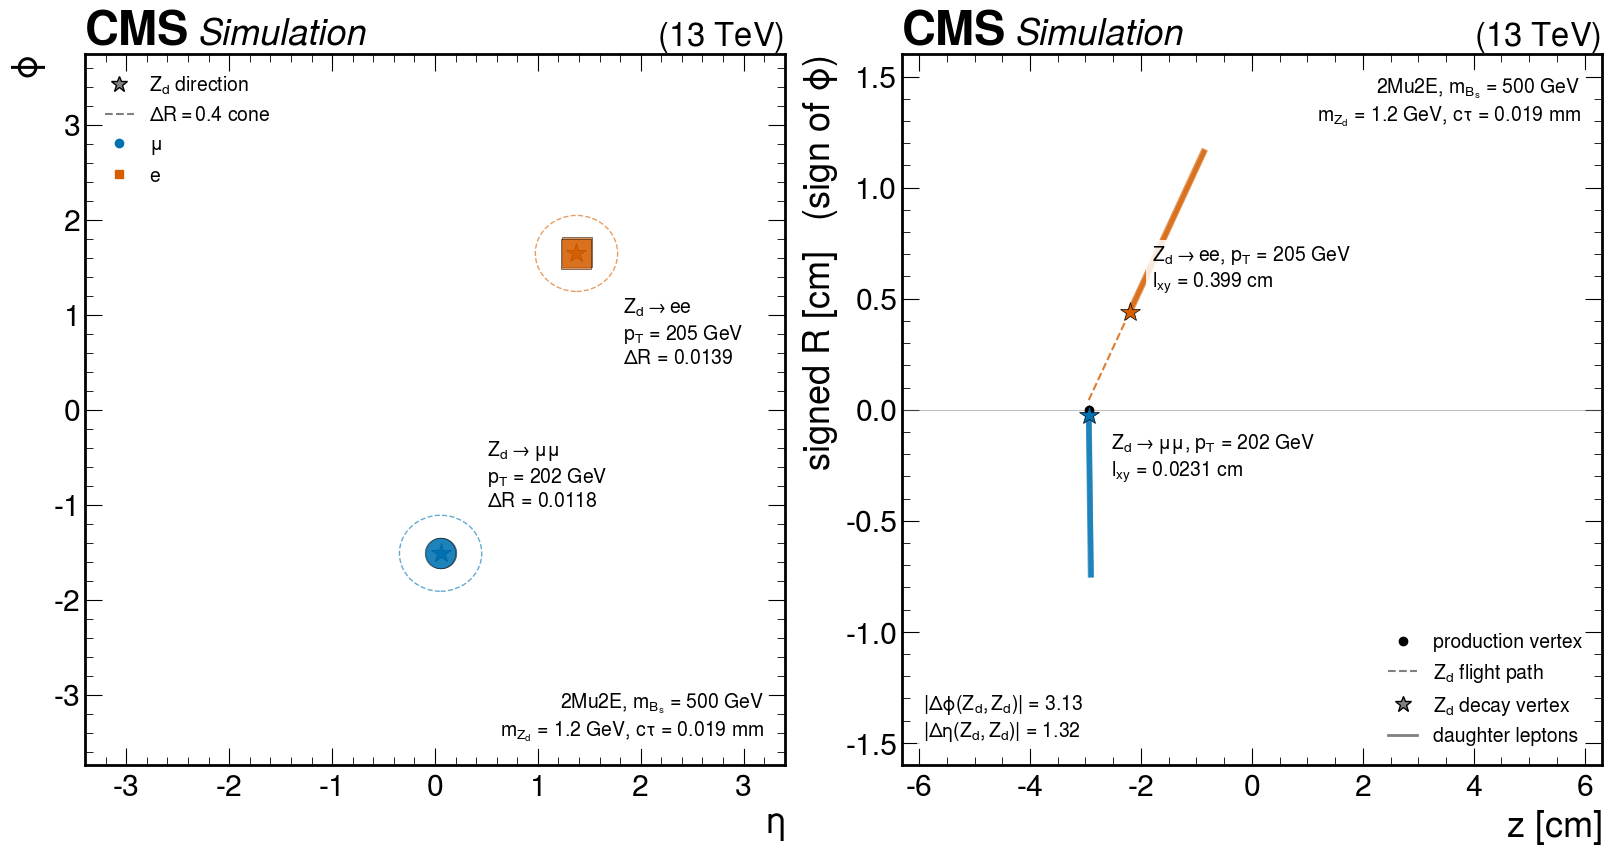

In [3]:
rec = display("2Mu2E_500GeV_1p2GeV_0p019mm", "signal_2mu2e_v10.yaml", "display_2mu2e_500_1p2")

**The analysis sweet spot.** Collimated muon pairs ($\Delta R \sim 0.02$) with decay vertices at the centimeter scale: beyond the beampipe, inside the pixel detector, displaced enough to kill prompt backgrounds, close enough that tracking still works.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_200_1p2.pdf
4Mu_200GeV_1p2GeV_0p48mm: event index 497 (sample median max-lxy = 4.08 cm)
  Zd->mumu: pT = 107 GeV, lxy = 0.537 cm, daughter pT = [11.5, 95.9] GeV
  Zd->mumu: pT = 93 GeV, lxy = 4.08 cm, daughter pT = [55.1, 37.5] GeV


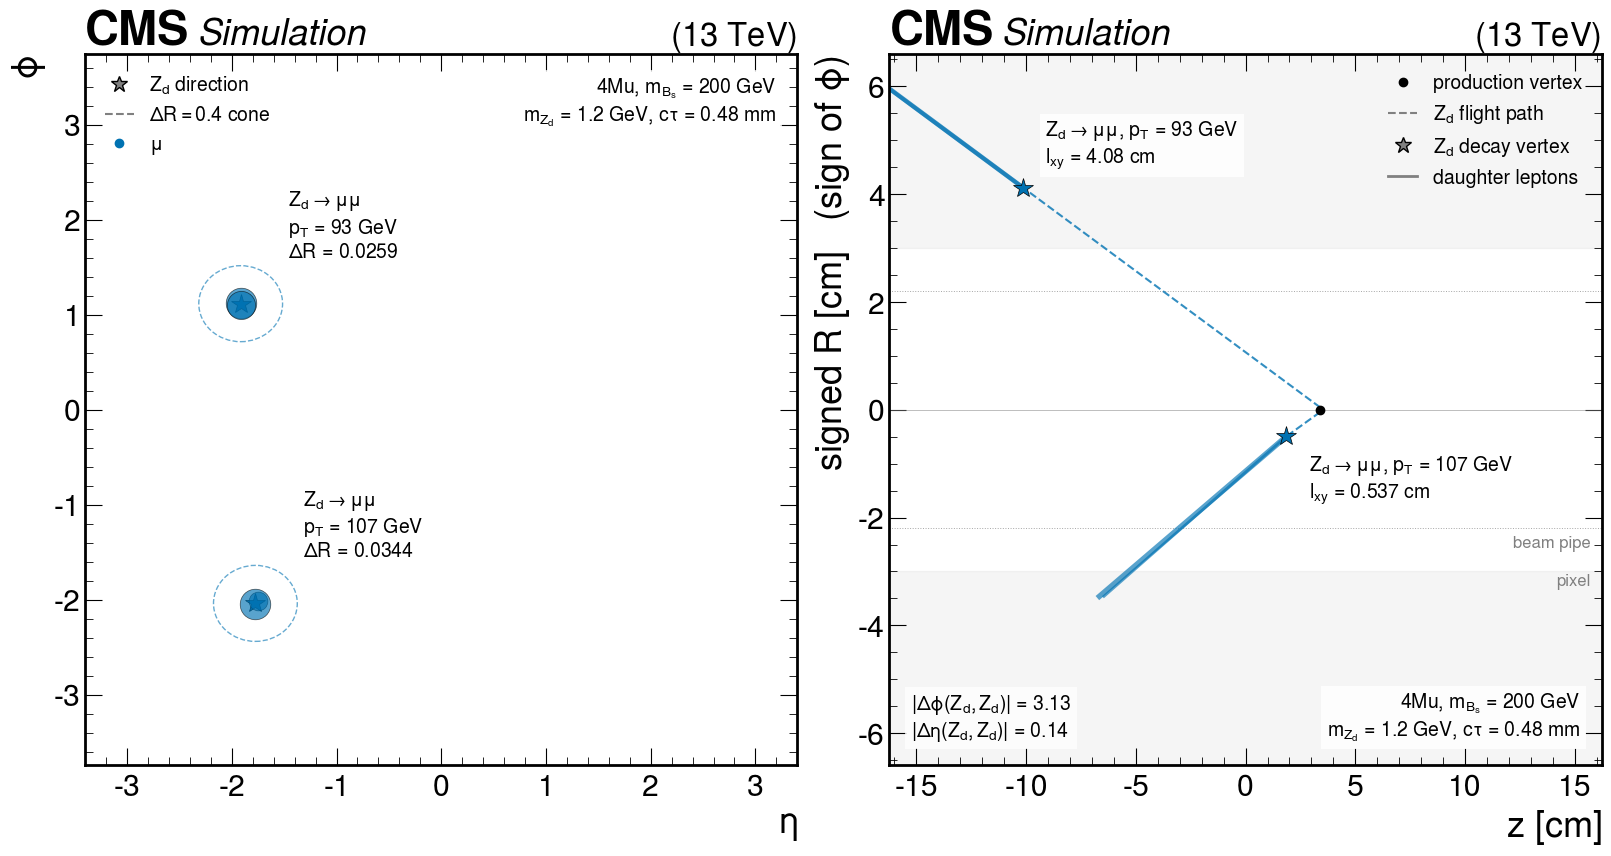

In [4]:
rec = display("4Mu_200GeV_1p2GeV_0p48mm", "signal_4mu_v10.yaml", "display_4mu_200_1p2")

**Extreme collimation.** At $m_{B_s} = 1000$ GeV each dark photon carries $p_T \sim 500$ GeV, and with $m_{Z_d} = 0.25$ GeV the pair opening angle is $\Delta R \sim 2m/p_T \sim 10^{-3}$, more than two orders of magnitude inside the clustering cone; only the annotation separates the two muons in the left panel. The boost also stretches the decay length to tens of centimeters despite $c\tau = 0.2$ mm.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_1000_0p25.pdf
4Mu_1000GeV_0p25GeV_0p2mm: event index 2821 (sample median max-lxy = 39.2 cm)
  Zd->mumu: pT = 297 GeV, lxy = 22.5 cm, daughter pT = [109.7, 186.8] GeV
  Zd->mumu: pT = 329 GeV, lxy = 39.3 cm, daughter pT = [123.5, 205.2] GeV


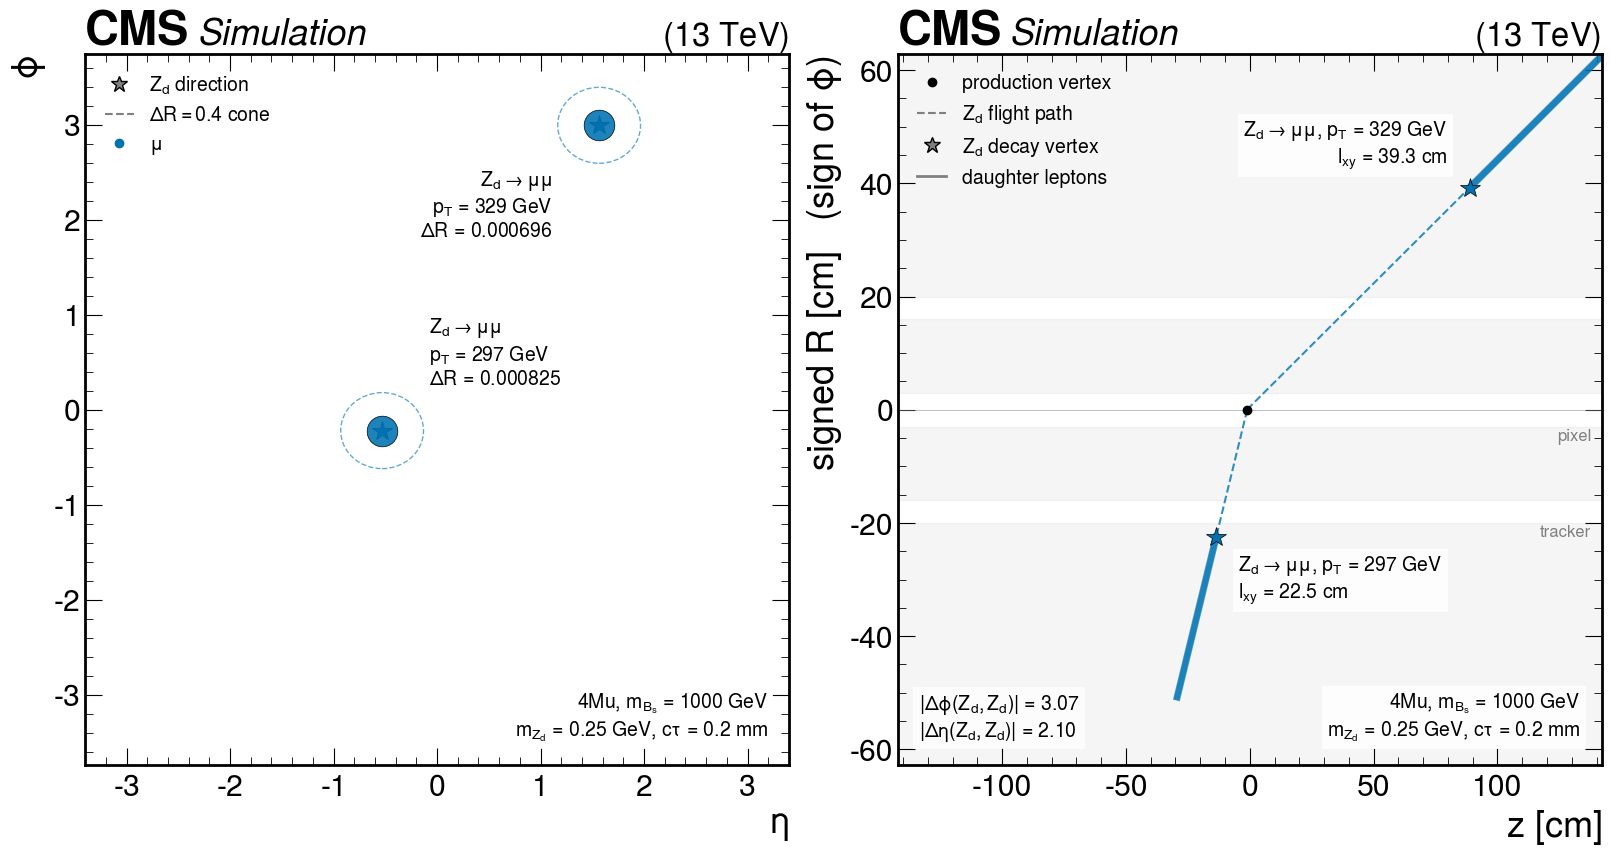

In [5]:
rec = display("4Mu_1000GeV_0p25GeV_0p2mm", "signal_4mu_v10.yaml", "display_4mu_1000_0p25")

**The wide, long-lived corner.** $m_{Z_d} = 5$ GeV against $p_T(Z_d) \sim 50$ GeV gives $\Delta R \sim 0.2$, an appreciable fraction of the cone size, and $c\tau = 200$ mm with $\beta\gamma \sim 10$ puts decay vertices at the meter scale, beyond the tracker, where only the muon pair remains reconstructable (as DSA muons).

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_100_5p0.pdf
2Mu2E_100GeV_5p0GeV_200mm: event index 702 (sample median max-lxy = 189 cm)
  Zd->mumu: pT = 44 GeV, lxy = 126 cm, daughter pT = [32.0, 11.9] GeV
  Zd->ee: pT = 57 GeV, lxy = 189 cm, daughter pT = [12.6, 44.7] GeV


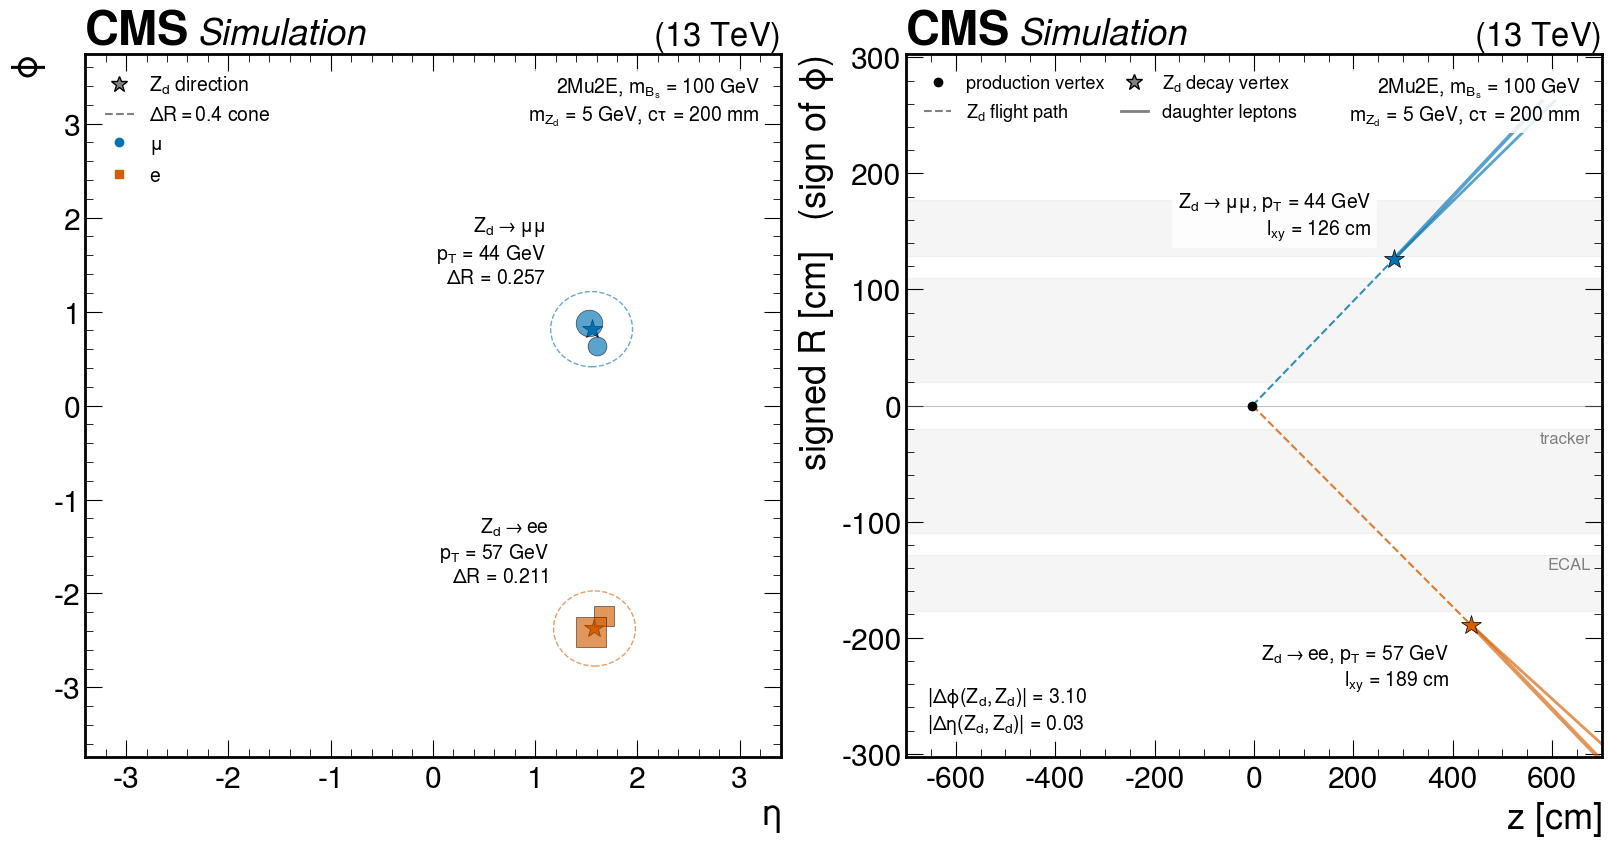

In [6]:
rec = display("2Mu2E_100GeV_5p0GeV_200mm", "signal_2mu2e_v10.yaml", "display_2mu2e_100_5p0")

**The trigger-marginal corner.** The lightest bound state with the lightest mediator: each muon carries roughly $m_{B_s}/4 \sim 25$ GeV, straddling the 23-25 GeV dimuon thresholds (marker areas scale with $p_T$, as in the corners above), while the pairs remain tightly collimated. This is the column where the trigger-efficiency maps of `trigger_context_forAN.ipynb` bottom out.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_100_0p25.pdf
4Mu_100GeV_0p25GeV_0p2mm: event index 3 (sample median max-lxy = 4.33 cm)
  Zd->mumu: pT = 63 GeV, lxy = 4.33 cm, daughter pT = [41.2, 22.0] GeV
  Zd->mumu: pT = 40 GeV, lxy = 0.282 cm, daughter pT = [16.0, 23.6] GeV


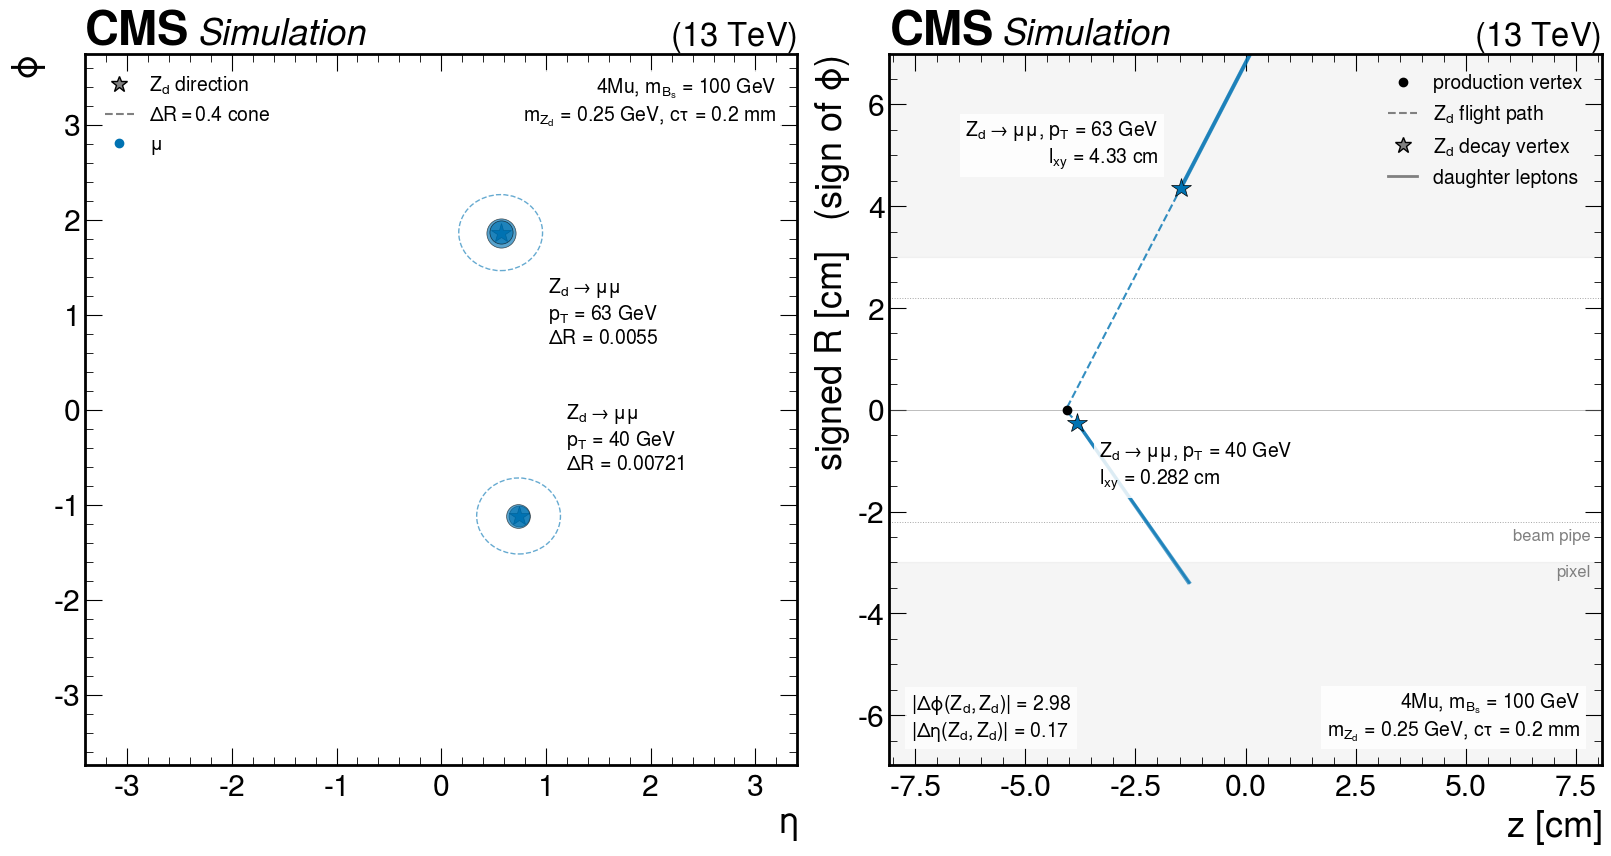

In [7]:
rec = display("4Mu_100GeV_0p25GeV_0p2mm", "signal_4mu_v10.yaml", "display_4mu_100_0p25")

**Beyond-tracker decays.** The longest lifetime of the sweet-spot mass point: decay vertices near or beyond the tracker envelope, where standard tracking is impossible and the event survives only through displaced-standalone (DSA) muons reconstructed in the muon system, the regime that motivates including DSA muons as lepton-jet constituents.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_200_1p2_long.pdf
4Mu_200GeV_1p2GeV_48p0mm: event index 1009 (sample median max-lxy = 285 cm)
  Zd->mumu: pT = 103 GeV, lxy = 285 cm, daughter pT = [51.6, 51.4] GeV
  Zd->mumu: pT = 85 GeV, lxy = 22.4 cm, daughter pT = [70.1, 14.5] GeV


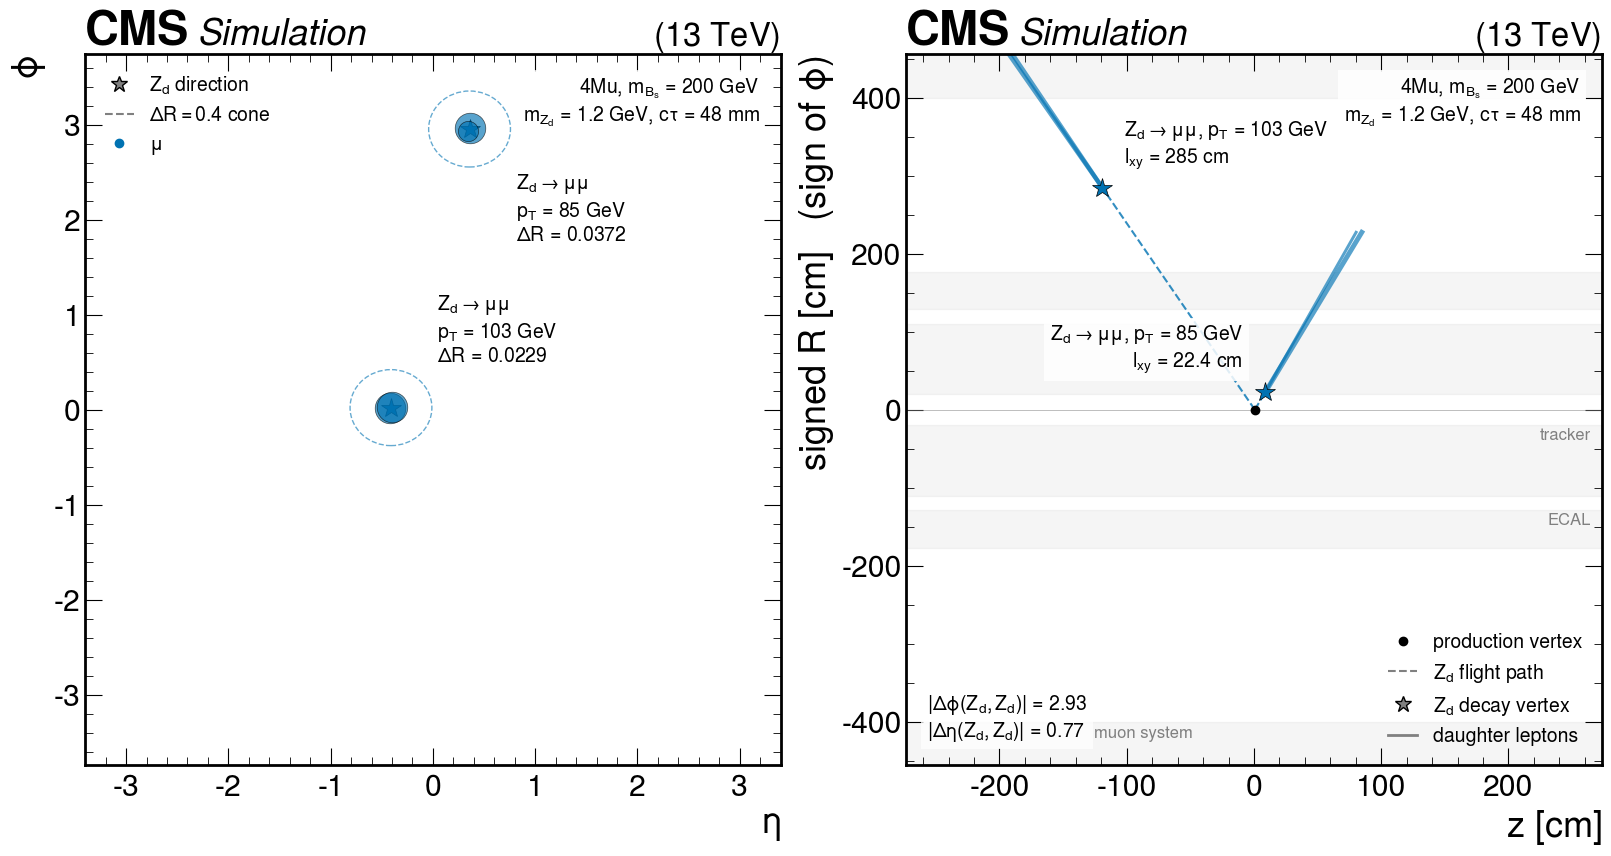

In [8]:
rec = display("4Mu_200GeV_1p2GeV_48p0mm", "signal_4mu_v10.yaml", "display_4mu_200_1p2_long")

**Just upstream of the muon system** (same mass point, event chosen at $l_{xy} \approx 350$ cm). The decay happens past the calorimeters and the solenoid, just inside the first muon station at $r \approx 400$ cm: nothing upstream records these muons (no tracker hits, no calorimeter deposits), but the full muon-system lever arm remains. This is the cleanest displaced-standalone reconstruction case.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_200_1p2_premuon.pdf
4Mu_200GeV_1p2GeV_48p0mm: event index 1162 (chosen closest to target lxy = 350 cm)
  Zd->mumu: pT = 92 GeV, lxy = 350 cm, daughter pT = [47.6, 44.3] GeV
  Zd->mumu: pT = 95 GeV, lxy = 3.43 cm, daughter pT = [84.7, 9.8] GeV


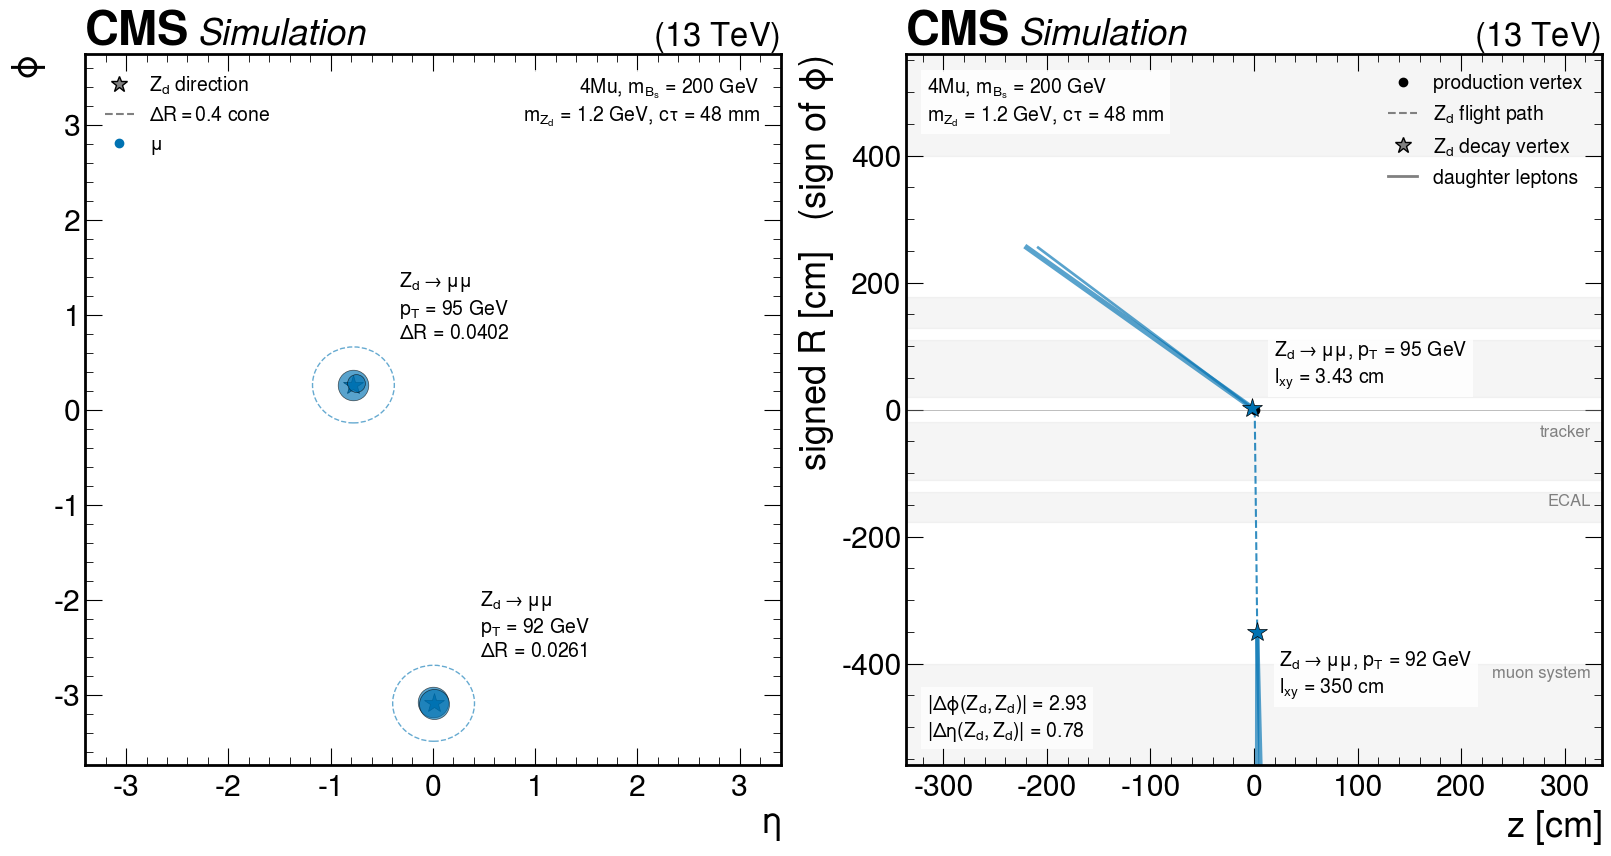

In [9]:
rec = display("4Mu_200GeV_1p2GeV_48p0mm", "signal_4mu_v10.yaml", "display_4mu_200_1p2_premuon", target_lxy=350)

**Inside the muon system** (the extreme-collimation point at $\beta\gamma \sim 10^3$, event chosen at $l_{xy} \approx 550$ cm). A $\Delta R \sim 10^{-3}$ muon pair materializes between the muon stations, leaving hits only in the outer chambers: the shortened lever arm degrades the standalone momentum measurement and the two muons share chambers, the far edge of reconstructability in displacement and collimation at once.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_4mu_500_0p25_muonsys.pdf
4Mu_500GeV_0p25GeV_4p0mm: event index 123 (chosen closest to target lxy = 550 cm)
  Zd->mumu: pT = 196 GeV, lxy = 553 cm, daughter pT = [131.0, 64.9] GeV
  Zd->mumu: pT = 209 GeV, lxy = 347 cm, daughter pT = [144.7, 64.8] GeV


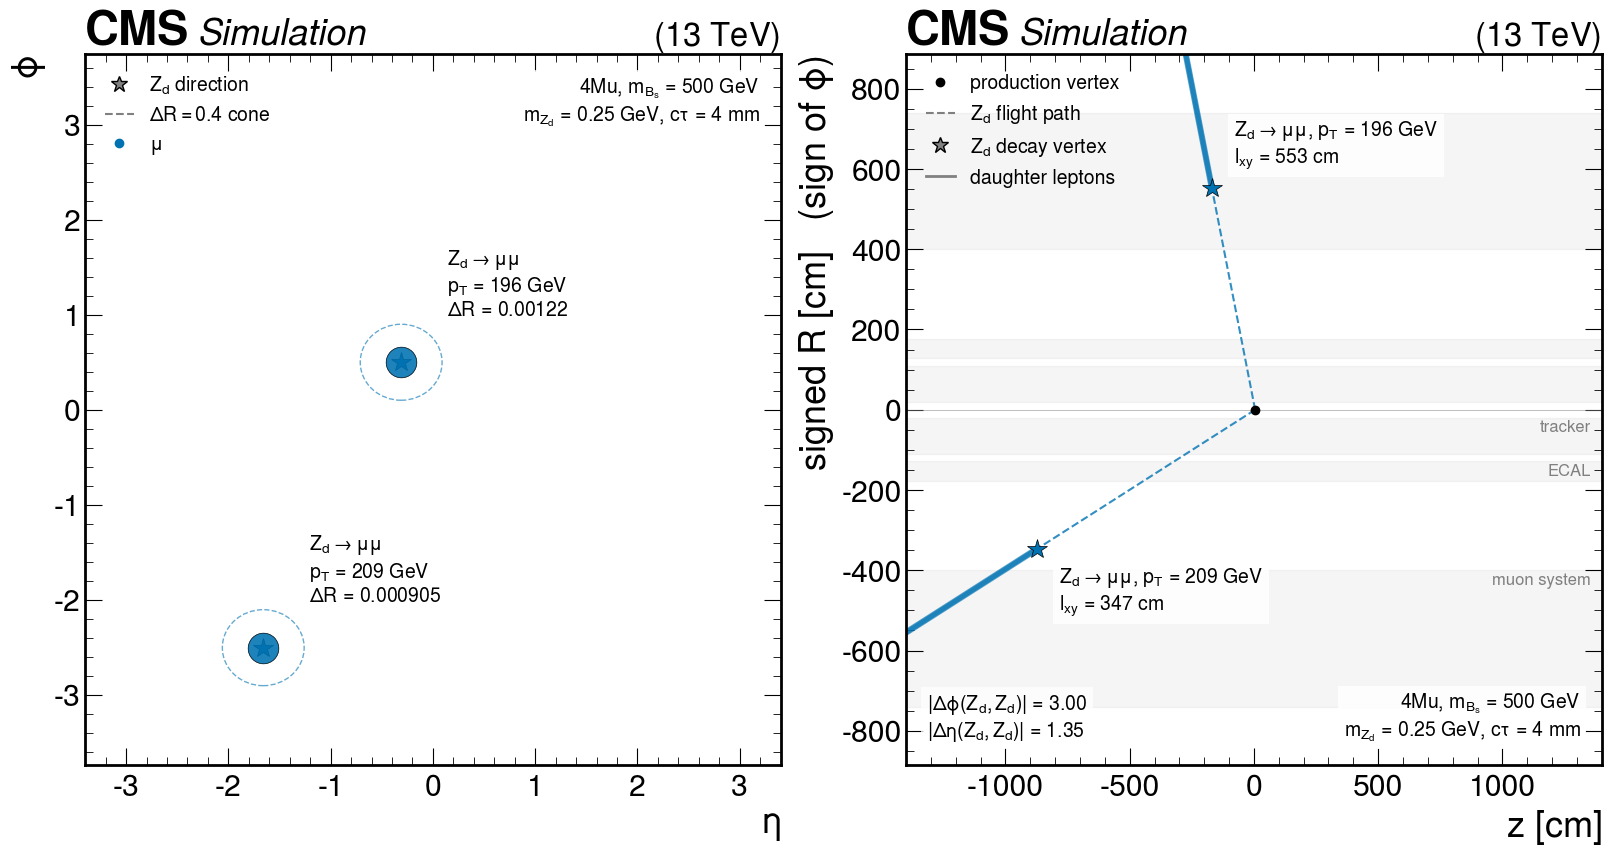

In [10]:
rec = display("4Mu_500GeV_0p25GeV_4p0mm", "signal_4mu_v10.yaml", "display_4mu_500_0p25_muonsys", target_lxy=550)

**The sweet spot in the electron channel.** The same mass and lifetime point as the 4Mu sweet-spot display: here one cone is a displaced *electron* jet, produced centimeters from the beamline inside the pixel detector, the regime where displaced-electron reconstruction and the photon-like lepton-jet constituents matter.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_200_1p2.pdf
2Mu2E_200GeV_1p2GeV_0p48mm: event index 1227 (sample median max-lxy = 4.12 cm)
  Zd->mumu: pT = 104 GeV, lxy = 2.11 cm, daughter pT = [52.6, 51.0] GeV
  Zd->ee: pT = 85 GeV, lxy = 4.12 cm, daughter pT = [66.3, 18.6] GeV


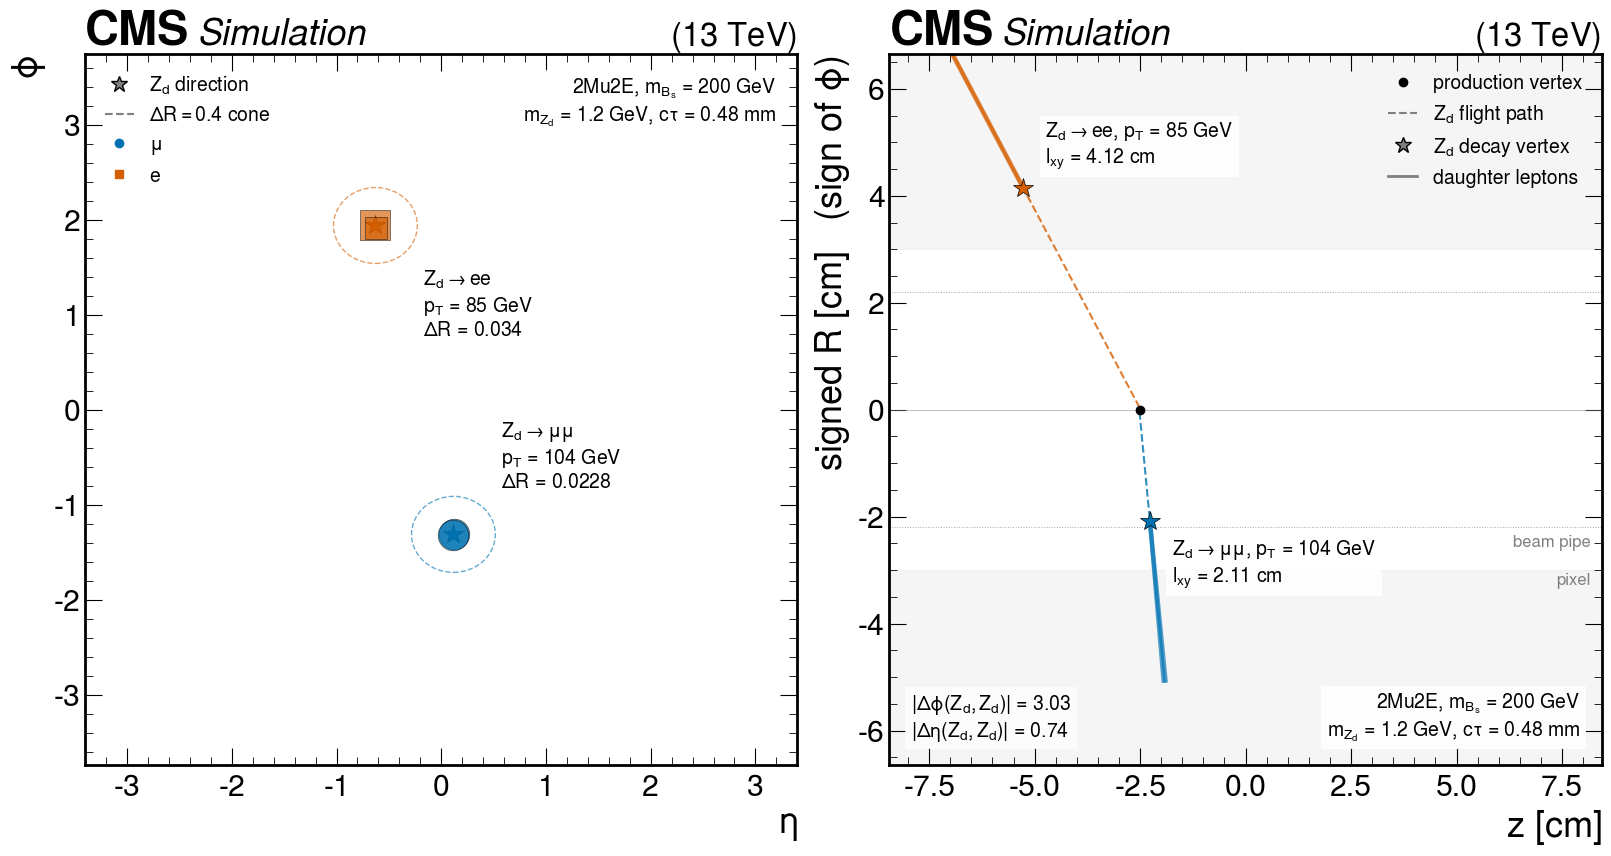

In [11]:
rec = display("2Mu2E_200GeV_1p2GeV_0p48mm", "signal_2mu2e_v10.yaml", "display_2mu2e_200_1p2")

**The hardest trigger corner of the electron channel.** The lightest bound state with the lightest mediator in 2Mu2E: the single soft, tightly collimated muon pair must fire the dimuon trigger alone (the electron pair cannot), which is where the 2Mu2E efficiency maps of `trigger_context_forAN.ipynb` reach their minimum.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:867: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_100_0p25.pdf
2Mu2E_100GeV_0p25GeV_0p2mm: event index 2217 (sample median max-lxy = 4.29 cm)
  Zd->mumu: pT = 38 GeV, lxy = 4.29 cm, daughter pT = [15.0, 23.2] GeV
  Zd->ee: pT = 34 GeV, lxy = 0.837 cm, daughter pT = [15.4, 18.4] GeV


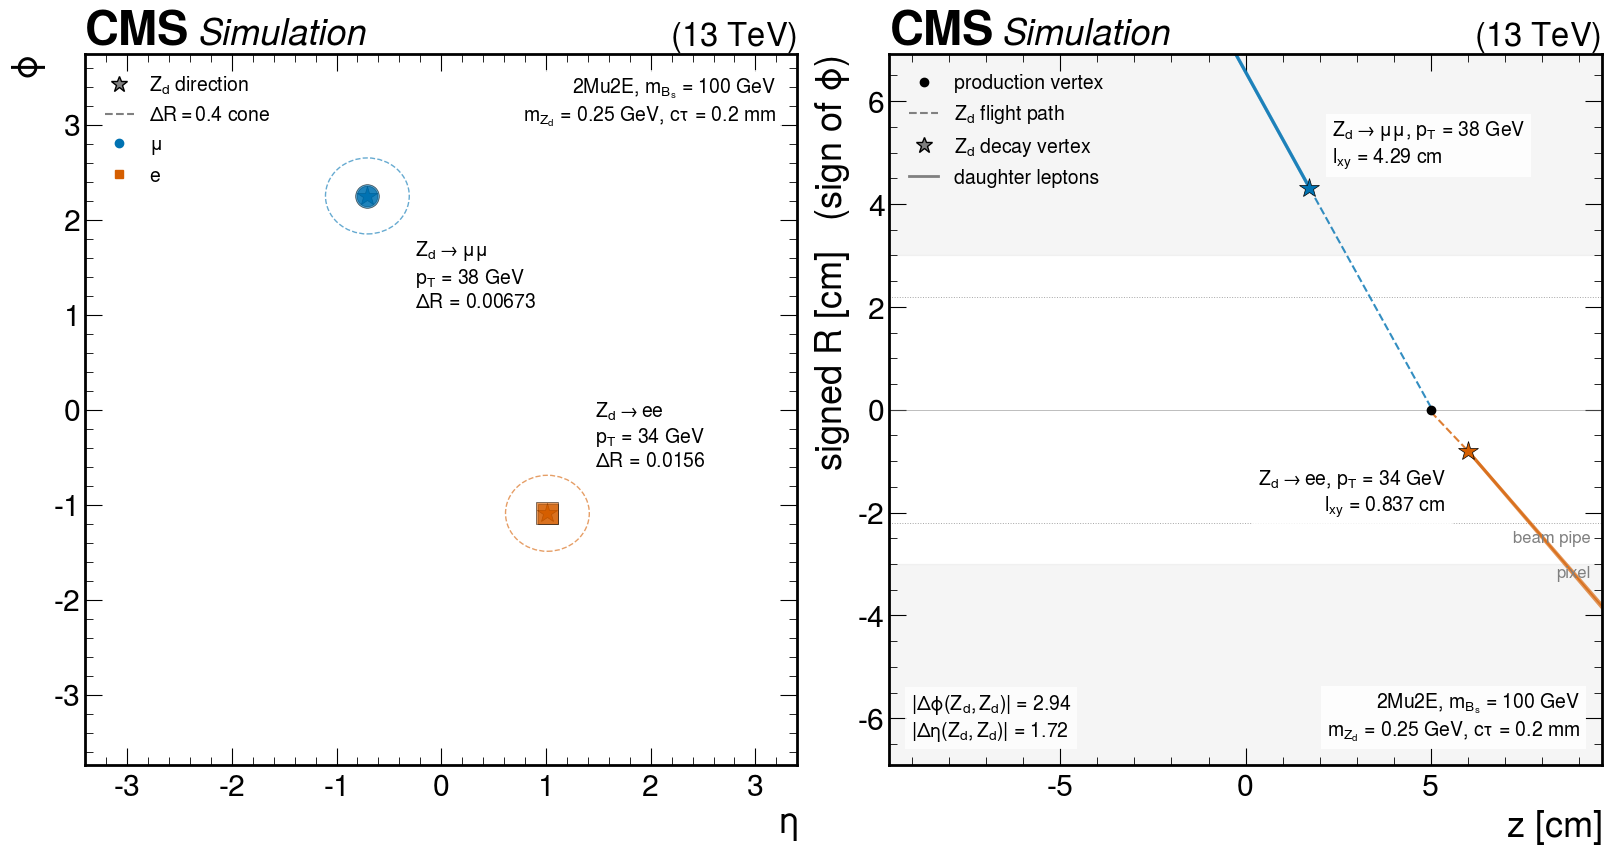

In [12]:
rec = display("2Mu2E_100GeV_0p25GeV_0p2mm", "signal_2mu2e_v10.yaml", "display_2mu2e_100_0p25")

**A late decay past the calorimeters** (event chosen at $l_{xy} \approx 250$ cm). Muons decaying this late still appear in the muon system as displaced-standalone tracks, but an electron pair born beyond the ECAL leaves no usable signal at all, the acceptance cost unique to this channel, and the reason its efficiency falls faster with lifetime than 4Mu's.

/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/uscms_data/d3/murtazas/SIDM/sidm_venv/lib/python3.11/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


saved /uscms_data/d3/murtazas/SIDM-wt-truthkin/sidm/studies/truth_kinematics_forAN/figures/display_2mu2e_200_1p2_late.pdf
2Mu2E_200GeV_1p2GeV_48p0mm: event index 422 (chosen closest to target lxy = 250 cm)
  Zd->mumu: pT = 46 GeV, lxy = 156 cm, daughter pT = [22.5, 23.2] GeV
  Zd->ee: pT = 46 GeV, lxy = 250 cm, daughter pT = [42.3, 4.0] GeV


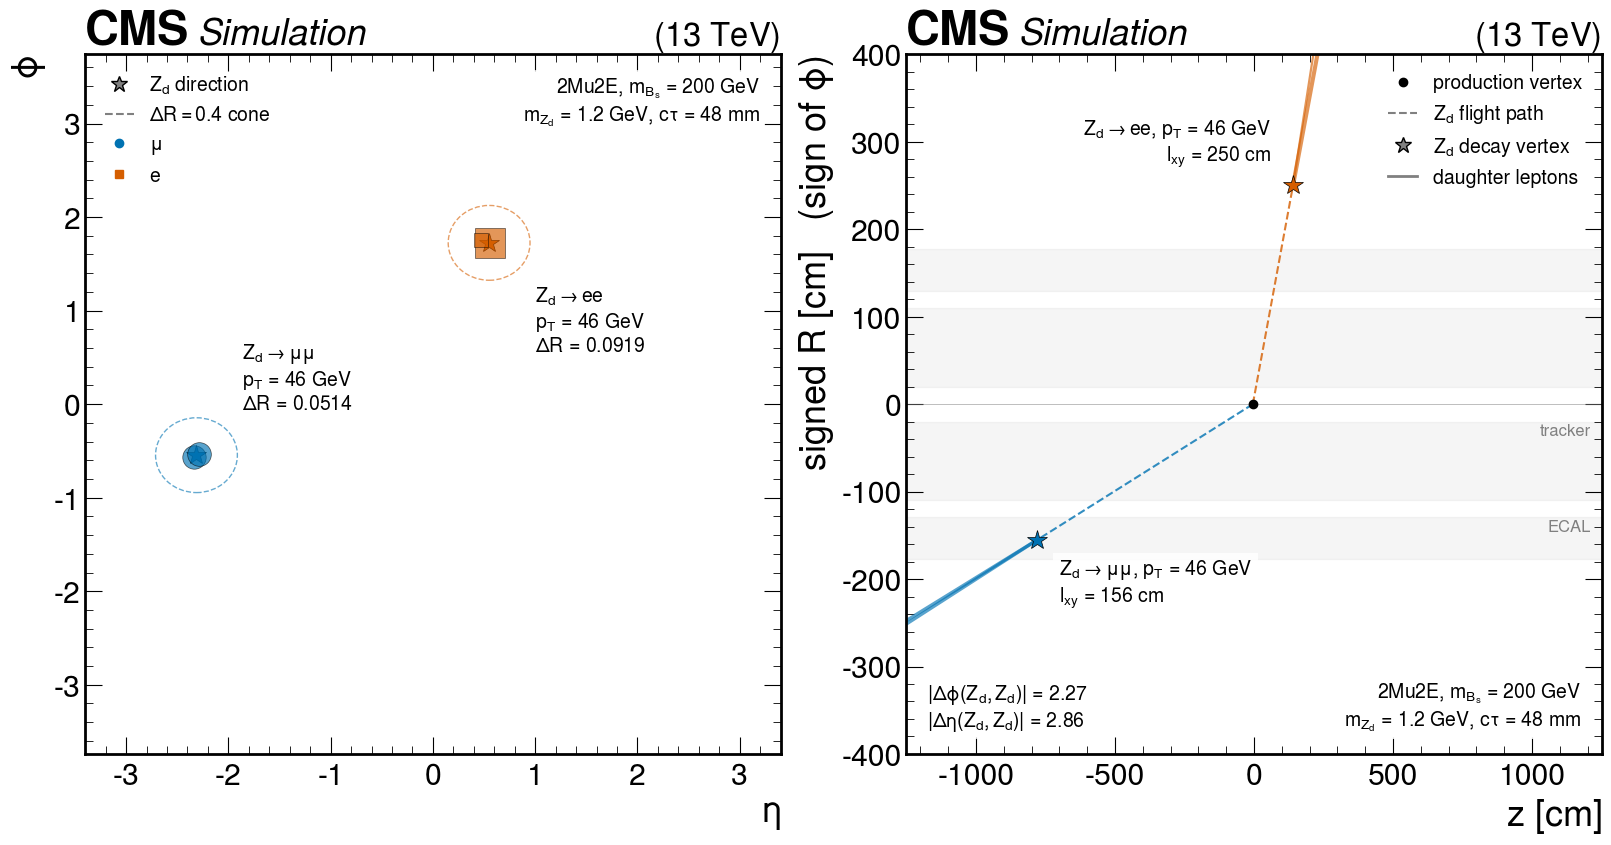

In [13]:
rec = display("2Mu2E_200GeV_1p2GeV_48p0mm", "signal_2mu2e_v10.yaml", "display_2mu2e_200_1p2_late", target_lxy=250)

Across every display the same three features recur: each dark photon's daughters stay inside a single $\Delta R = 0.4$ cone (collimation), the two cones sit at $\Delta\phi \approx \pi$ (back-to-back production), and the decay vertices sweep from the beamline to the muon system as $c\tau$ and boost vary (displacement). These are the features the lepton-jet definition, the displaced triggers, and the vertex-based selections are built around; the distributions behind each of them are shown in `final_state_anatomy_forAN.ipynb`.